# Workshop 1 - Sturdy-Octo-Disco-Adding-Sunglasses-for-a-Cool-New-Look
## Name: ARAVINDAN SD
## Reg No: 212224243001

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Face')

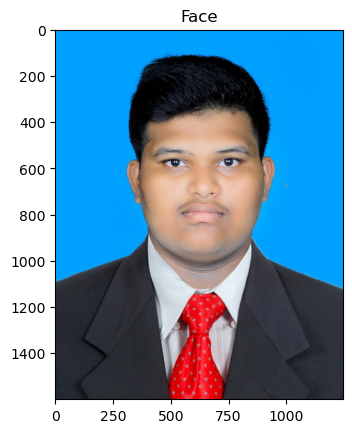

In [2]:
# Load the Face Image
faceImage = cv2.imread('my.jpg')
plt.imshow(faceImage[:,:,::-1]);plt.title("Face")


In [3]:
faceImage.shape

(1600, 1244, 3)

In [4]:
#resized_faceImage.shape
faceImage.shape

(1600, 1244, 3)

Text(0.5, 1.0, 'glassPNG')

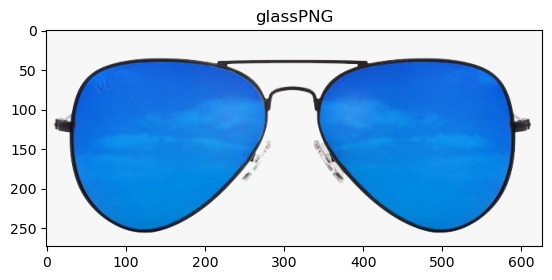

In [5]:
# Load the Sunglass image with Alpha channel
# (http://pluspng.com/sunglass-png-1104.html)
glassPNG = cv2.imread('glass.jpg',-1)
plt.imshow(glassPNG[:,:,::-1]);plt.title("glassPNG")

In [8]:
# Resize the image to fit over the eye region
glassPNG = cv2.resize(glassPNG,(820,300))
print("image Dimension ={}".format(glassPNG.shape))

image Dimension =(300, 820, 3)


In [61]:
# Separate the Color and alpha channels
glassBGR = glassPNG[:,:,0:3]
glassMask1 = glassPNG[:,:,:3]
print(glassPNG.shape)

(300, 820, 3)


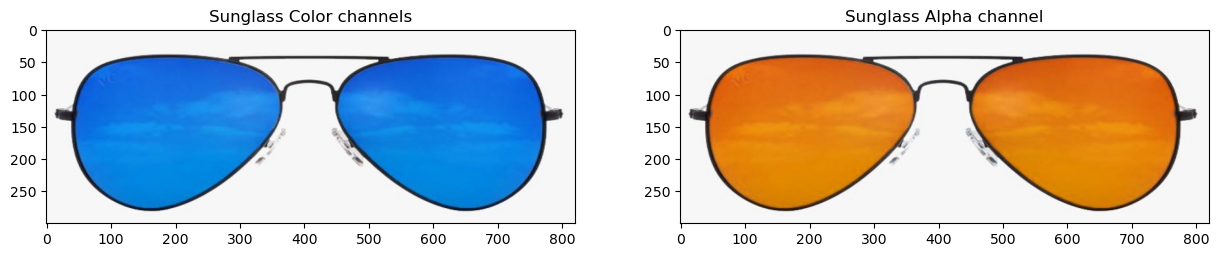

In [62]:
# Display the images for clarity
plt.figure(figsize=[15,15])
plt.subplot(121);plt.imshow(glassBGR[:,:,::-1]);plt.title('Sunglass Color channels');
plt.subplot(122);plt.imshow(glassMask1,cmap='gray');plt.title('Sunglass Alpha channel');

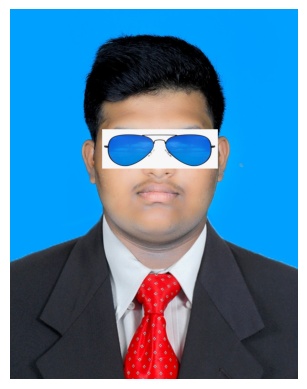

In [63]:
# Resize the glasses
glassBGR = cv2.resize(glassBGR, (500, 170))

# Copy the image
faceWithGlassesNaive = faceImage.copy()

# Adjust the position
x = 398    # Left/Right
y = 520    # Up/Down

# Place the glasses
faceWithGlassesNaive[y:y+170, x:x+500] = glassBGR

# Display
plt.imshow(faceWithGlassesNaive[:,:,::-1])
plt.axis("off")
plt.show()

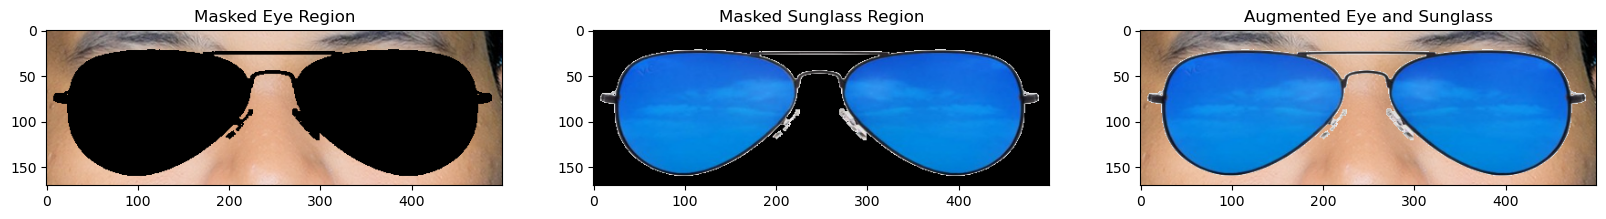

In [71]:
# Resize glasses
w = 500
h = 170

glassBGR = cv2.resize(glassBGR, (w, h))

# Create mask from white background
gray = cv2.cvtColor(glassBGR, cv2.COLOR_BGR2GRAY)

_, glassMask = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY_INV)

glassMask = cv2.merge((glassMask, glassMask, glassMask))
glassMask = glassMask.astype(np.float32) / 255.0

# Copy image
faceWithGlassesArithmetic = faceImage.copy()

# Position
x = 398
y = 520

# ROI
eyeROI = faceWithGlassesArithmetic[y:y+h, x:x+w].astype(np.float32)

glassBGR = glassBGR.astype(np.float32)

# Arithmetic operations
maskedEye = eyeROI * (1 - glassMask)
maskedGlass = glassBGR * glassMask

eyeRoiFinal = cv2.add(maskedEye, maskedGlass)

# Display intermediate images
plt.figure(figsize=(20,8))

plt.subplot(131)
plt.imshow(np.uint8(maskedEye)[:,:,::-1])
plt.title("Masked Eye Region")

plt.subplot(132)
plt.imshow(np.uint8(maskedGlass)[:,:,::-1])
plt.title("Masked Sunglass Region")

plt.subplot(133)
plt.imshow(np.uint8(eyeRoiFinal)[:,:,::-1])
plt.title("Augmented Eye and Sunglass")

plt.show()

# Put result back into face
faceWithGlassesArithmetic[y:y+h, x:x+w] = np.uint8(eyeRoiFinal)

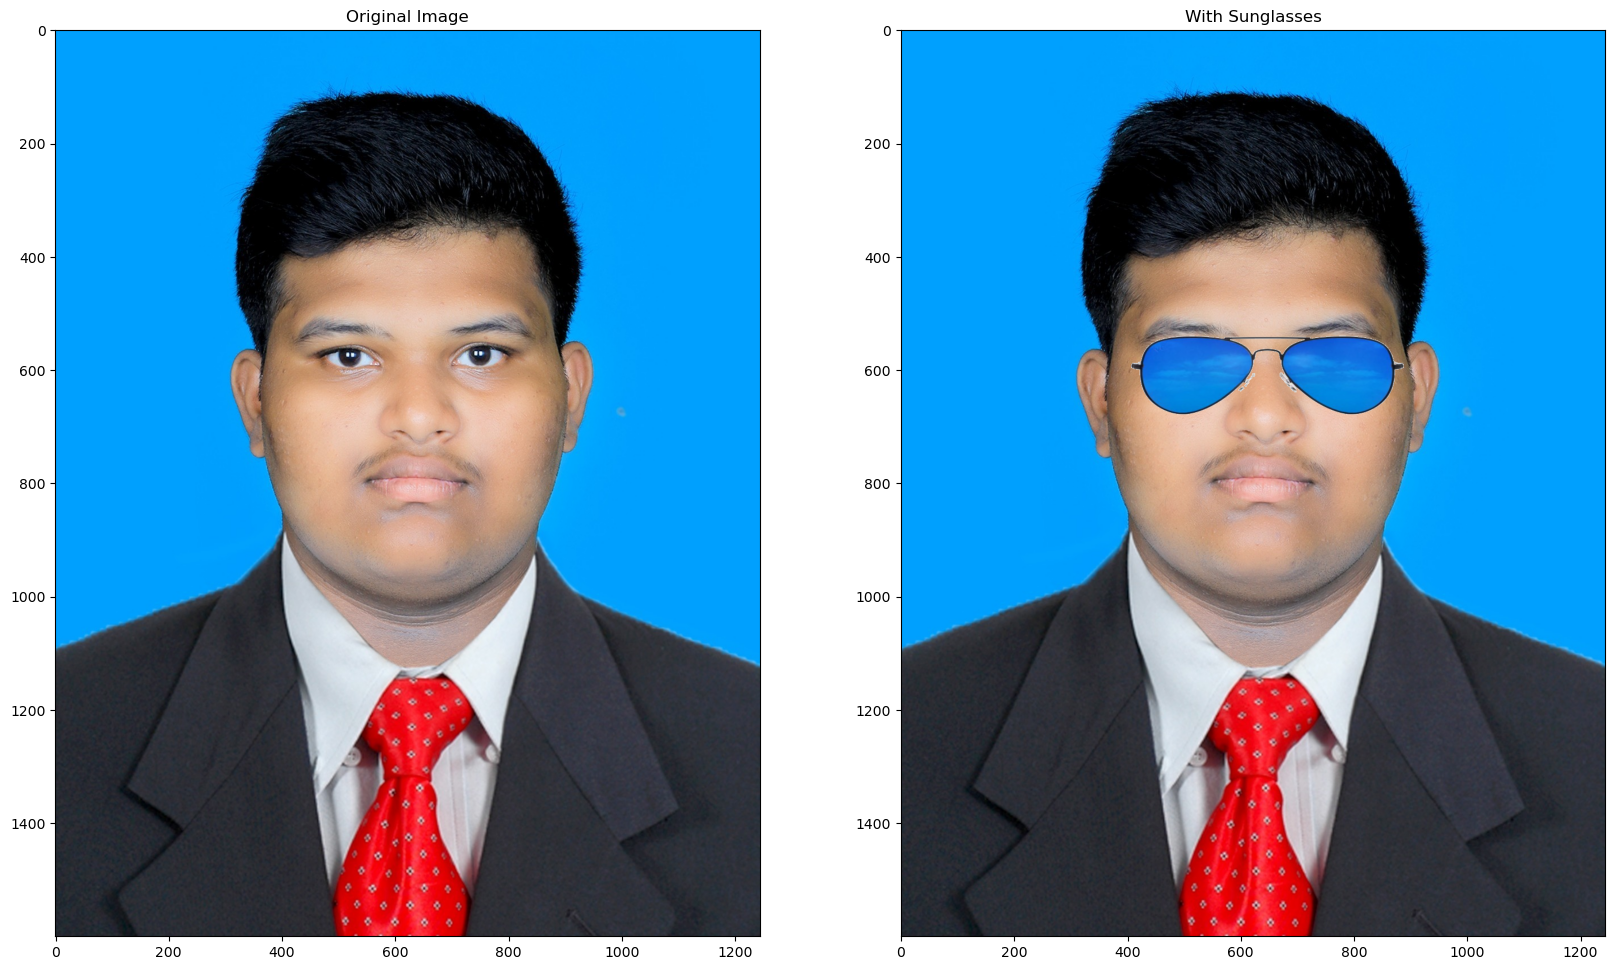

In [72]:
plt.figure(figsize=(20,20))

plt.subplot(121)
plt.imshow(faceImage[:,:,::-1])
plt.title("Original Image")

plt.subplot(122)
plt.imshow(faceWithGlassesArithmetic[:,:,::-1])
plt.title("With Sunglasses")

plt.show()